In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# import statsmodels.formula.api as smf

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV, LeaveOneOut, cross_val_score, cross_val_predict
from sklearn.metrics import mean_squared_error, r2_score
from linearmodels.system import SUR

In [2]:
df = pd.read_excel('./datasets/swatch.xlsx')
df

,Sample,평량(g/m2),BET(m2/g),SWATCH(GD) 24h(Con),SWATCH(HD) 24h(Con)
0,ACF25-01,105.20,1150,320,280
1,ACF25-02,99.30,1450,470,220
2,ACF25-03,119.70,1150,1150,550
3,ACF25-04,110.40,1300,850,850
4,ACF25-05,103.44,1016,470,580
5,ACF25-06,122.83,1080,20,140
6,ACF25-07,154.49,1139,380,10
7,ACF25-08,140.00,1300,20,5
8,ACF25-09,130.00,2197,50,5


In [3]:
import statsmodels.formula.api as smf

for y in ['SWATCH(GD) 24h(Con)', 'SWATCH(HD) 24h(Con)']:
    m = smf.ols(f'Q("{y}") ~ Q("평량(g/m2)") + Q("BET(m2/g)")', data=df).fit()
    print(f'\n== {y} ==')
    print(m.summary())


== SWATCH(GD) 24h(Con) ==
                               OLS Regression Results                               
Dep. Variable:     Q("SWATCH(GD) 24h(Con)")   R-squared:                       0.182
Model:                                  OLS   Adj. R-squared:                 -0.091
Method:                       Least Squares   F-statistic:                    0.6664
Date:                      Fri, 01 May 2026   Prob (F-statistic):              0.548
Time:                              13:51:35   Log-Likelihood:                -64.937
No. Observations:                         9   AIC:                             135.9
Df Residuals:                             6   BIC:                             136.5
Df Model:                                 2                                         
Covariance Type:                  nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------

c:\Programming\Anaconda\Lib\site-packages\scipy\stats\_stats_py.py:1971: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=9
  k, _ = kurtosistest(a, axis)
c:\Programming\Anaconda\Lib\site-packages\scipy\stats\_stats_py.py:1971: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=9
  k, _ = kurtosistest(a, axis)


In [5]:
df_scaled = df.copy()
pairs = [
    ('평량(g/m2)', 'BET(m2/g)', 'SWATCH(GD) 24h(Con)', 'SWATCH(HD) 24h(Con)'),
]
x1_col, x2_col, y1_col, y2_col = pairs[0]

scaler = StandardScaler()
df_scaled[[x1_col, x2_col]] = scaler.fit_transform(df[[x1_col, x2_col]])
df_scaled

,Sample,평량(g/m2),BET(m2/g),SWATCH(GD) 24h(Con),SWATCH(HD) 24h(Con)
0,ACF25-01,-0.887485,-0.471169,320,280
1,ACF25-02,-1.227594,0.417208,470,220
2,ACF25-03,-0.051625,-0.471169,1150,550
3,ACF25-04,-0.587728,-0.026980,850,850
4,ACF25-05,-0.988941,-0.867977,470,580
5,ACF25-06,0.128806,-0.678457,20,140
6,ACF25-07,1.953863,-0.503742,380,10
7,ACF25-08,1.118579,-0.026980,20,5
8,ACF25-09,0.542124,2.629266,50,5


In [7]:
df_sur = df_scaled.rename(columns={
    x1_col: 'weight',
    x2_col: 'BET',
    y1_col: 'GD',
    y2_col: 'HD'
}).copy()

df_sur['weight2'] = df_sur['weight'] ** 2
df_sur['BET2'] = df_sur['BET'] ** 2
df_sur['weight_BET'] = df_sur['weight'] * df_sur['BET']

eqs = {
    'GD': 'GD ~ 1 + weight + BET',
    'HD': 'HD ~ 1 + weight + BET'
}

model = SUR.from_formula(eqs, data=df_sur)
res = model.fit()

print(res.summary)

                           System GLS Estimation Summary                           
Estimator:                        GLS   Overall R-squared:                   0.2856
No. Equations.:                     2   McElroy's R-squared:                 0.3311
No. Observations:                   9   Judge's (OLS) R-squared:             0.2856
Date:                Fri, May 01 2026   Berndt's R-squared:                  0.5038
Time:                        13:51:50   Dhrymes's R-squared:                 0.2856
                                        Cov. Estimator:                      robust
                                        Num. Constraints:                      None
                     Equation: GD, Dependent Variable: GD                     
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
Intercept      414.44     109.69     3.7784     0.0002      199.46      629.43
weight      

In [8]:
pred = res.fitted_values
print(pred)

           GD          HD
0  557.084650  477.631957
1  507.391879  461.943778
2  466.064366  339.887404
3  481.078587  392.365929
4  606.871408  526.393360
5  466.653215  326.891971
6  250.858506   12.025790
7  295.271663  111.177048
8   98.725727   -8.317238


In [9]:
params = res.params
print(params)

GD_Intercept    414.444444
GD_weight      -108.894154
GD_BET          -97.625950
HD_Intercept    293.333333
HD_weight      -164.793779
HD_BET          -80.749495
Name: params, dtype: float64


In [10]:
df_sur['pred_GD'] = (
    params['GD_Intercept']
    + params['GD_weight'] * df_sur['weight']
    + params['GD_BET'] * df_sur['BET']
)

df_sur['pred_HD'] = (
    params['HD_Intercept']
    + params['HD_weight'] * df_sur['weight']
    + params['HD_BET'] * df_sur['BET']
)

In [11]:
from sklearn.metrics import r2_score

r2_GD = r2_score(df_sur['GD'], df_sur['pred_GD'])
r2_HD = r2_score(df_sur['HD'], df_sur['pred_HD'])

print("R^2 GD:", r2_GD)
print("R^2 HD:", r2_HD)

R^2 GD: 0.18176393937605306
R^2 HD: 0.45412210887584625


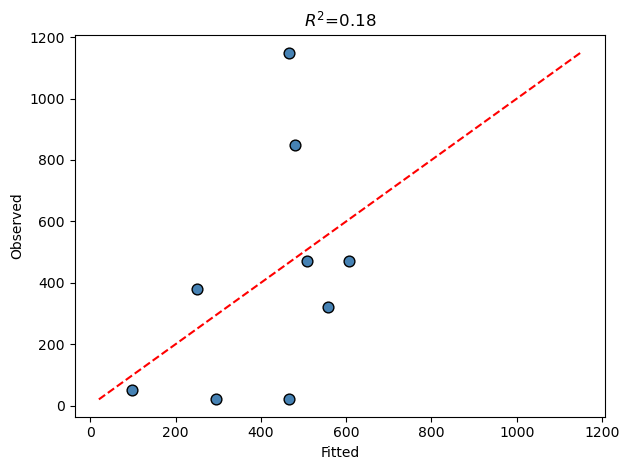

In [12]:
# Pred vs. Observed
fig, ax = plt.subplots()

pred_GD = df_sur['pred_GD']
true_y_GD = df[y1_col]

ax.scatter(pred_GD, true_y_GD, color='steelblue', edgecolors='black', s=60)

# 기준선
ax.plot([true_y_GD.min(), true_y_GD.max()], [true_y_GD.min(), true_y_GD.max()],
        linestyle='--', color='red')
# for idx, (xi, yi) in enumerate(zip(pred_GD, true_y_GD)):
#     ax.annotate(samples[idx], (xi, yi),
#                 fontsize=7, xytext=(3, 3), textcoords='offset points')

ax.set_xlabel('Fitted')
ax.set_ylabel('Observed')
ax.set_title(f'$R^{2}$={r2_GD:.2f}')

plt.tight_layout()
plt.show()

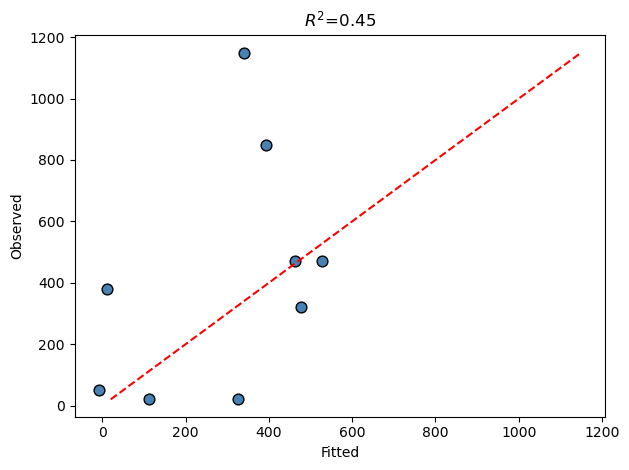

In [13]:
# Pred vs. Observed
fig, ax = plt.subplots()

pred_HD = df_sur['pred_HD']
true_y_HD = df[y1_col]

ax.scatter(pred_HD, true_y_HD, color='steelblue', edgecolors='black', s=60)

# 기준선
ax.plot([true_y_HD.min(), true_y_HD.max()], [true_y_HD.min(), true_y_HD.max()],
        linestyle='--', color='red')
# for idx, (xi, yi) in enumerate(zip(pred_GD, true_y_GD)):
#     ax.annotate(samples[idx], (xi, yi),
#                 fontsize=7, xytext=(3, 3), textcoords='offset points')

ax.set_xlabel('Fitted')
ax.set_ylabel('Observed')
ax.set_title(f'$R^{2}$={r2_HD:.2f}')

plt.tight_layout()
plt.show()

# 다항 + 릿지

In [14]:
df_sur = df_scaled.rename(columns={
    x1_col: 'weight',
    x2_col: 'BET',
    y1_col: 'GD',
    y2_col: 'HD'
}).copy()

df_sur['weight2'] = df_sur['weight'] ** 2
df_sur['BET2'] = df_sur['BET'] ** 2
df_sur['weight_BET'] = df_sur['weight'] * df_sur['BET']

eqs = {
    'GD': 'GD ~ 1 + weight + BET + weight2 + BET2 + weight_BET',
    'HD': 'HD ~ 1 + weight + BET + weight2 + BET2 + weight_BET'
}

model = SUR.from_formula(eqs, data=df_sur)
res = model.fit()

print(res.summary)

                           System GLS Estimation Summary                           
Estimator:                        GLS   Overall R-squared:                   0.3416
No. Equations.:                     2   McElroy's R-squared:                 0.4615
No. Observations:                   9   Judge's (OLS) R-squared:             0.3416
Date:                Fri, May 01 2026   Berndt's R-squared:                  0.6714
Time:                        13:52:13   Dhrymes's R-squared:                 0.3416
                                        Cov. Estimator:                      robust
                                        Num. Constraints:                      None
                     Equation: GD, Dependent Variable: GD                     
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
Intercept      509.64     247.51     2.0591     0.0395      24.526      994.75
weight      

# log y + SUR

In [19]:
df_scaled['log_GD'] = np.log(df_scaled[y1_col].values)
df_scaled['log_HD'] = np.log(df_scaled[y2_col].values)
df_scaled

,Sample,평량(g/m2),BET(m2/g),SWATCH(GD) 24h(Con),SWATCH(HD) 24h(Con),log_GD,log_HD
0,ACF25-01,-0.887485,-0.471169,320,280,5.768321,5.634790
1,ACF25-02,-1.227594,0.417208,470,220,6.152733,5.393628
2,ACF25-03,-0.051625,-0.471169,1150,550,7.047517,6.309918
3,ACF25-04,-0.587728,-0.026980,850,850,6.745236,6.745236
4,ACF25-05,-0.988941,-0.867977,470,580,6.152733,6.363028
5,ACF25-06,0.128806,-0.678457,20,140,2.995732,4.941642
6,ACF25-07,1.953863,-0.503742,380,10,5.940171,2.302585
7,ACF25-08,1.118579,-0.026980,20,5,2.995732,1.609438
8,ACF25-09,0.542124,2.629266,50,5,3.912023,1.609438


In [21]:
df_sur = df_scaled.rename(columns={
    x1_col: 'weight',
    x2_col: 'BET',
    'log_GD': 'GD',
    'log_HD': 'HD'
}).copy()

df_sur['weight2'] = df_sur['weight'] ** 2
df_sur['BET2'] = df_sur['BET'] ** 2
df_sur['weight_BET'] = df_sur['weight'] * df_sur['BET']

eqs = {
    'GD': 'GD ~ 1 + weight + BET',
    'HD': 'HD ~ 1 + weight + BET'
}

model = SUR.from_formula(eqs, data=df_sur)
res = model.fit()

print(res.summary)

                           System GLS Estimation Summary                           
Estimator:                        GLS   Overall R-squared:                   0.6170
No. Equations.:                     2   McElroy's R-squared:                 0.7483
No. Observations:                   9   Judge's (OLS) R-squared:             0.6170
Date:                Fri, May 01 2026   Berndt's R-squared:                  0.8560
Time:                        13:55:24   Dhrymes's R-squared:                 0.6170
                                        Cov. Estimator:                      robust
                                        Num. Constraints:                      None
                     Equation: GD, Dependent Variable: GD                     
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
Intercept      5.3011     0.4328     12.250     0.0000      4.4529      6.1493
weight      

In [22]:
df_sur = df_scaled.rename(columns={
    x1_col: 'weight',
    x2_col: 'BET',
    'log_GD': 'GD',
    'log_HD': 'HD'
}).copy()

df_sur['weight2'] = df_sur['weight'] ** 2
df_sur['BET2'] = df_sur['BET'] ** 2
df_sur['weight_BET'] = df_sur['weight'] * df_sur['BET']

eqs = {
    'GD': 'GD ~ 1 + weight + BET + weight2 + BET2 + weight_BET',
    'HD': 'HD ~ 1 + weight + BET + weight2 + BET2 + weight_BET'
}

model = SUR.from_formula(eqs, data=df_sur)
res = model.fit()

print(res.summary)

                           System GLS Estimation Summary                           
Estimator:                        GLS   Overall R-squared:                   0.7022
No. Equations.:                     2   McElroy's R-squared:                 0.9447
No. Observations:                   9   Judge's (OLS) R-squared:             0.7022
Date:                Fri, May 01 2026   Berndt's R-squared:                  0.9801
Time:                        13:56:27   Dhrymes's R-squared:                 0.7022
                                        Cov. Estimator:                      robust
                                        Num. Constraints:                      None
                     Equation: GD, Dependent Variable: GD                     
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
Intercept      4.6679     0.9471     4.9285     0.0000      2.8116      6.5242
weight      